## **Modelo Árbol de decisión mejorado V1**

Importar librerías necesarias

In [38]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

from scipy.sparse import hstack

In [39]:
# Guardando el dataset como un dataframe
df = pd.read_csv("/content/df16to25.csv")
df.head()

,id,stars,review_body,review_title,language,product_category,lenght_review_body,lenght_review_title,lenght_product_category
0,151766,4,Mando aceptable precio un poco caro.. pero cum...,Cumple su funcion,es,electronics,134,17,11
1,10209,5,Muy chula y se ha pegado muy bien al maletero ...,Bruja grande,es,automotive,75,12,10
2,197887,5,Me gustó mucho como idea para regalos funcionó...,Idea genial,es,home,51,11,4
3,68193,1,"A los seis meses de uso deja de funcionar, es ...",Decepcionante,es,wireless,64,13,8
4,149127,3,"Para un rato vale,pero no agarra mucho y para ...",Que para algunos juegos no vale,es,video_games,97,31,11


Crear la variable Sentimiento

In [40]:
def sentimiento(stars):
    if stars <= 2:
        return 'Negativo'
    elif stars == 3:
        return 'Neutro'
    else:
        return 'Positivo'

df['sentiment'] = df['stars'].apply(sentimiento)

df.head()

,id,stars,review_body,review_title,language,product_category,lenght_review_body,lenght_review_title,lenght_product_category,sentiment
0,151766,4,Mando aceptable precio un poco caro.. pero cum...,Cumple su funcion,es,electronics,134,17,11,Positivo
1,10209,5,Muy chula y se ha pegado muy bien al maletero ...,Bruja grande,es,automotive,75,12,10,Positivo
2,197887,5,Me gustó mucho como idea para regalos funcionó...,Idea genial,es,home,51,11,4,Positivo
3,68193,1,"A los seis meses de uso deja de funcionar, es ...",Decepcionante,es,wireless,64,13,8,Negativo
4,149127,3,"Para un rato vale,pero no agarra mucho y para ...",Que para algunos juegos no vale,es,video_games,97,31,11,Neutro


Crear Dataframe separados por estrellas

In [41]:
df_1 = df[df['stars'] == 1]
df_2 = df[df['stars'] == 2]
df_3 = df[df['stars'] == 3]
df_4 = df[df['stars'] == 4]
df_5 = df[df['stars'] == 5]

Seleccionar variables más relevantes para el modelo

In [42]:
X_texto = df['review_body']          # Texto del comentario
X_longitud = df[['lenght_review_body']]  # Longitud del comentario
y = df['sentiment']                  # Variable objetivo

Vectorización del texto

In [43]:
vectorizer_tree = TfidfVectorizer(
    max_features=300,   # limita el número de palabras
    ngram_range=(1,1),  # solo palabras individuales
    min_df=2            # ignora palabras que aparecen solo una vez
)

X_texto_vec = vectorizer_tree.fit_transform(X_texto)

Unir o concatenar las columnas texto(review body) + longitud del comentario

In [44]:
X_final = hstack([X_texto_vec, X_longitud.values])

Separando los datos de entrenamiento y prueba para el modelo

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    stratify=y,      # mantiene proporción de clases de las distintas categorias de comentarios (Positivo, negativo, neutro)
    random_state=42
)

Creando el modelo del Árbol de Decisión (controlado o mejorado)

In [46]:
tree_model = DecisionTreeClassifier(
    max_depth=5,          # limita la profundidad del árbol para evitar que no pueda generalizár con nuevos datos
    min_samples_leaf=5,   # evita hojas con muy pocos datos
    class_weight='balanced',
    random_state=42
)

Entrenando el modelo Árbol de Decisión (mejorado)

In [47]:
#El Árbol va a aprender reglas a partir de los datos o registros sumnistrados en el dataframe
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=5,
                       random_state=42)

Se procede a evaluar el Modelo

In [48]:
# Para resaltar la idea es que el modelo prediga las 3 clases, tambien que no todo sea neutro y que el accuracy sea honesto (0.45–0.55)
y_pred_tree = tree_model.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Accuracy Árbol de Decisión:", round(accuracy_tree, 2))
print(classification_report(y_test, y_pred_tree))

Accuracy Árbol de Decisión: 0.5
              precision    recall  f1-score   support

    Negativo       0.33      0.67      0.44         6
      Neutro       0.67      0.40      0.50         5
    Positivo       0.80      0.44      0.57         9

    accuracy                           0.50        20
   macro avg       0.60      0.50      0.51        20
weighted avg       0.63      0.50      0.52        20



Se crea la función limpiar texto

In [49]:
# Se importa la biblioteca re para normalizar el texto y evitar que el modelo trate como diferentes palabras que en realidad son iguales.
import re

def limpiar_texto(texto):
    """
    Limpia el texto:
    - Convierte a minúsculas
    - Elimina caracteres especiales
    - Elimina espacios extras
    """
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúñ\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

Se crea la función para la predicción del sentimiento

In [50]:
def predecir_sentimiento_arbol(texto):
    # Limpieza del texto para normalizarlo
    texto_limpio = limpiar_texto(texto)

    # Vectorización del texto
    texto_vec = vectorizer_tree.transform([texto_limpio])

    # Esta es la variable numérica: longitud del texto
    longitud = np.array([[len(texto_limpio)]])

    # Unión o contatenación de features o caracterés
    X_nuevo = hstack([texto_vec, longitud])

    # Predicción
    sentimiento = tree_model.predict(X_nuevo)[0]

    return f"Sentimiento (Árbol de Decisión): {sentimiento} | Precisión del modelo: {round(accuracy_tree, 2)}"

**Prueba del modelo**

In [51]:
#El modelo del Árbol de decisión (Controlado o mejorado) se mantiene con una precisión de 0.55 pero al igual que su primera versión aún continua sin reconocer adecuadamente los sentimientos negativos
predecir_sentimiento_arbol("Lamentable")


'Sentimiento (Árbol de Decisión): Negativo | Precisión del modelo: 0.5'

**Métricas** Precisión(Accuracy), Recall(Sensibilidad), F1-Score(Puntuación única(de 0 a 1) que indica el rendimiento general de un modelo de clasificación).

In [52]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

    Negativo       0.33      0.67      0.44         6
      Neutro       0.67      0.40      0.50         5
    Positivo       0.80      0.44      0.57         9

    accuracy                           0.50        20
   macro avg       0.60      0.50      0.51        20
weighted avg       0.63      0.50      0.52        20



**Entrenando el Modelo Árbol de decisión con los nuevos datasets 200/500/5000 y completo**

In [53]:
# Se carga el dataset completo para tenerlo como población base y mismas muestras de distribución.
df = pd.read_csv('df_completo.csv')

In [54]:
df.head()

,id,review_body,stars,language,lenght_review_body,review_body_clean,sentiment
0,111516,No llegaron las hélices,1,es,23,no llegaron las hélices,negativo
1,107084,Me encanta lo ligera y manejable que es. Plega...,4,es,420,me encanta lo ligera y manejable que es plegad...,positivo
2,199386,"De las dos baterias , hay una que no funciona",1,es,45,de las dos baterias hay una que no funciona,negativo
3,69470,"la iluminación es genial, pero el adhesivo pos...",2,es,105,la iluminación es genial pero el adhesivo post...,negativo
4,114836,La he comprado porque por estética y colores e...,4,es,165,la he comprado porque por estética y colores e...,positivo


In [55]:
# Se cargan los datasets con registros de diferentes tamaños 500/1000/5000
df_500 = pd.read_csv('df_500_fx.csv')
df_1000 = pd.read_csv('df_1000_fx.csv')
df_5000 = pd.read_csv('df_5000_fx.csv')

**Se crea función de muestreo aleatorío**

In [56]:
#El proposito de este muestreo es para garantizar reproducibilidad y flexibilidad en los experimentos. Además el muestreo es controlado.
def muestreo_aleatorio(df, n):
    """
    Devuelve una muestra aleatoria de tamaño n
    """
    return df.sample(n=n, random_state=42)

In [57]:
# Selección de variables
def preparar_datos(df):
    X_texto = df['review_body_clean']
    X_longitud = df[['lenght_review_body']]
    y = df['sentiment']
    return X_texto, X_longitud, y

**Función para el Árbol de decisión**

In [58]:
def entrenar_arbol_decision(df, arbol_decisionv1):
    print(f"\n📊 Entrenando modelo Árbol de decisión con dataset: {arbol_decisionv1}")

    # Eliminar filas con NaN en las columnas relevantes antes de preparar los datos
    df_cleaned = df.dropna(subset=['review_body_clean', 'lenght_review_body', 'sentiment'])

    # Preparar datos o variables
    X_texto = df_cleaned['review_body_clean']
    X_longitud = df_cleaned[['lenght_review_body']]
    y = df_cleaned['sentiment']

    # División train / test
    X_text_train, X_text_test, X_len_train, X_len_test, y_train, y_test = train_test_split(
        X_texto,
        X_longitud,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Vectorización del texto
    vectorizer = TfidfVectorizer(
        max_features=3000,
        ngram_range=(1,2),
        min_df=2
    )

    X_text_train_vec = vectorizer.fit_transform(X_text_train)
    X_text_test_vec = vectorizer.transform(X_text_test)

    # Unión o concatenación del texto + longitud
    X_train_final = hstack([X_text_train_vec, X_len_train])
    X_test_final = hstack([X_text_test_vec, X_len_test])

    # Árbol de Decisión mejorado
    model = DecisionTreeClassifier(
        max_depth=12,
        min_samples_split=15,
        min_samples_leaf=7,
        class_weight='balanced',
        random_state=42
    )

    # Entrenamiento del modelo
    model.fit(X_train_final, y_train)

    # Evaluación del modelo
    y_pred = model.predict(X_test_final)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Accuracy: {accuracy:.3f}")
    print(classification_report(y_test, y_pred))

    # Devolvemos lo necesario para realizar prueba más adelante
    return model, vectorizer, accuracy

### **Entrenar al modelo por tamaños**

**Entrenamiento #1**

In [59]:
model_500, vectorizer_500, acc_500 = entrenar_arbol_decision(df_500, "500 registros")
model_1000, vectorizer_1000, acc_1000 = entrenar_arbol_decision(df_1000, "1000 registros")
model_5000, vectorizer_5000, acc_5000 = entrenar_arbol_decision(df_5000, "5000 registros")


📊 Entrenando modelo Árbol de decisión con dataset: 500 registros
Accuracy: 0.550
              precision    recall  f1-score   support

    negativo       0.62      0.60      0.61        40
      neutro       0.29      0.35      0.32        20
    positivo       0.65      0.60      0.62        40

    accuracy                           0.55       100
   macro avg       0.52      0.52      0.52       100
weighted avg       0.56      0.55      0.56       100


📊 Entrenando modelo Árbol de decisión con dataset: 1000 registros
Accuracy: 0.485
              precision    recall  f1-score   support

    negativo       0.54      0.41      0.47        80
      neutro       0.25      0.40      0.31        40
    positivo       0.63      0.60      0.62        80

    accuracy                           0.48       200
   macro avg       0.48      0.47      0.46       200
weighted avg       0.52      0.48      0.50       200


📊 Entrenando modelo Árbol de decisión con dataset: 5000 registros
Accura

**Entrenamiento #2**

In [60]:
# Se entrena el modelo Árbol de decisión pero ahora añadiendo el dataset completo y retirando el dataset de 500 registros
model_1000, vectorizer_1000, acc_1000 = entrenar_arbol_decision(df_1000, "1000 registros")
model_5000, vectorizer_5000, acc_5000 = entrenar_arbol_decision(df_5000, "5000 registros")
model_completo, vectorizer_completo, acc_completo = entrenar_arbol_decision(df, "Dataset completo")


📊 Entrenando modelo Árbol de decisión con dataset: 1000 registros
Accuracy: 0.485
              precision    recall  f1-score   support

    negativo       0.54      0.41      0.47        80
      neutro       0.25      0.40      0.31        40
    positivo       0.63      0.60      0.62        80

    accuracy                           0.48       200
   macro avg       0.48      0.47      0.46       200
weighted avg       0.52      0.48      0.50       200


📊 Entrenando modelo Árbol de decisión con dataset: 5000 registros
Accuracy: 0.534
              precision    recall  f1-score   support

    negativo       0.64      0.47      0.54       402
      neutro       0.32      0.49      0.39       200
    positivo       0.61      0.62      0.62       398

    accuracy                           0.53      1000
   macro avg       0.53      0.53      0.52      1000
weighted avg       0.57      0.53      0.54      1000


📊 Entrenando modelo Árbol de decisión con dataset: Dataset completo
Acc

### **Función para guardar métricas completas**

In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [62]:
def guardar_metricas_completas(
    df,
    model,
    vectorizer,
    nombre_modeloarbol,
    nombre_datasetmetricas
):
    """
    Guarda métricas completas (por clase + globales) en un CSV
    """

    # Eliminar filas con NaN en las columnas relevantes
    df_cleaned = df.dropna(subset=['review_body_clean', 'lenght_review_body', 'sentiment'])

    # 1️⃣ Variables
    X_texto = df_cleaned["review_body_clean"]
    X_longitud = df_cleaned[['lenght_review_body']] # Include length feature
    y = df_cleaned["sentiment"]

    # 2️⃣ Train / Test
    # Split both text and length features consistently with training
    X_text_train, X_text_test, X_len_train, X_len_test, y_train, y_test = train_test_split(
        X_texto,
        X_longitud, # Add X_longitud to the split
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # 3️⃣ Vectorizar texto
    X_test_vec = vectorizer.transform(X_text_test)

    # 4️⃣ Combine text vector with length feature for prediction
    X_test_final = hstack([X_test_vec, X_len_test]) # Combine features for prediction

    # 5️⃣ Predicción
    y_pred = model.predict(X_test_final) # Predict using the combined features

    # 6️⃣ Classification report como diccionario
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    # 7️⃣ Convertir a DataFrame
    df_report = pd.DataFrame(report).transpose()

    # 8️⃣ Agregar metadata
    df_report["Modelo"] = nombre_modeloarbol
    df_report["Dataset"] = nombre_datasetmetricas

    # 9️⃣ Reordenar columnas
    columnas = [
        "Modelo",
        "Dataset",
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
    df_report = df_report[columnas]

    # 🔟 Guardar CSV
    nombre_archivo = f"metricas_completas_{nombre_modeloarbol}_{nombre_datasetmetricas}.csv"
    df_report.to_csv(nombre_archivo)

    print(f"✔️ Métricas completas guardadas en: {nombre_archivo}")

### **Guardar métricas completas por tamaño de dataset**

In [63]:
#Métricas 1000 registros
guardar_metricas_completas(
    df_1000,
    model_1000,
    vectorizer_1000,
    "ArbolDecision",
    "1000"
)

✔️ Métricas completas guardadas en: metricas_completas_ArbolDecision_1000.csv


In [64]:
# Métricas 5000 registros
guardar_metricas_completas(
    df_5000,
    model_5000,
    vectorizer_5000,
    "ArbolDecision",
    "5000"
)

✔️ Métricas completas guardadas en: metricas_completas_ArbolDecision_5000.csv


In [65]:
#Métricas dataset completo
guardar_metricas_completas(
    df,
    model_completo,
    vectorizer_completo,
    "ArbolDecision",
    "completo"
)

✔️ Métricas completas guardadas en: metricas_completas_ArbolDecision_completo.csv


###Métricas y matriz de confusión

Para cada modelo y dataset:

1️⃣ Métricas

🔹Accuracy

🔹Precision (macro)

🔹Recall (macro)

🔹F1-score (macro)

2️⃣ Matriz de confusión

🔹Valores numéricos

🔹En formato tabular (.csv)

Importación de librerías

In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

### Función para evaliar y guardar los resultados

Esta función se crea principalmente para:

Evalúar el modelo, guardar métricas, guardar matriz de confusión

In [67]:
def evaluar_y_guardar_resultados(
    df,
    model,
    vectorizer,
    nombre_modelo,
    nombre_dataset
):
    """
    Evalúa el modelo y guarda métricas y matriz de confusión en CSV
    """

    # 1️⃣ Variables
    X_texto = df["review_body_clean"]
    X_longitud = df[['lenght_review_body']]
    y = df["sentiment"]

    # 2️⃣ Train / Test
    X_text_train, X_text_test, X_len_train, X_len_test, y_train, y_test = train_test_split(
        X_texto,
        X_longitud,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # 3️⃣ Vectorizar texto
    X_test_vec = vectorizer.transform(X_text_test)

    # 4️⃣ Unir variables (texto vectorizado + longitud)
    X_test_final = hstack([X_test_vec, X_len_test])

    # 5️⃣ Predicción
    y_pred = model.predict(X_test_final)

    # 6️⃣ Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    # 7️⃣ Guardar métricas
    df_metricas = pd.DataFrame([{
        "Modelo": nombre_modelo,
        "Dataset": nombre_dataset,
        "Accuracy": round(accuracy, 4),
        "Precision_macro": round(precision, 4),
        "Recall_macro": round(recall, 4),
        "F1_macro": round(f1, 4)
    }])

    nombre_metricas = f"metricas_{nombre_modelo}_{nombre_dataset}.csv"
    df_metricas.to_csv(nombre_metricas, index=False)

    # 8️⃣ Matriz de confusión
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=model.classes_
    )

    df_cm = pd.DataFrame(
        cm,
        index=model.classes_,
        columns=model.classes_
    )

    nombre_cm = f"confusion_{nombre_modelo}_{nombre_dataset}.csv"
    df_cm.to_csv(nombre_cm)

    print(f"✔️ Guardados: {nombre_metricas} y {nombre_cm}")

### Guardar individualmente los datasets con diferentes tamaños

In [68]:
#Dataset con 1000 registros
evaluar_y_guardar_resultados(
    df_1000,
    model_1000,
    vectorizer_1000,
    "ArbolDecision",
    "1000"
)

✔️ Guardados: metricas_ArbolDecision_1000.csv y confusion_ArbolDecision_1000.csv


In [69]:
#Dataset con 5000 registros
evaluar_y_guardar_resultados(
    df_5000,
    model_5000,
    vectorizer_5000,
    "ArbolDecision",
    "5000"
)

✔️ Guardados: metricas_ArbolDecision_5000.csv y confusion_ArbolDecision_5000.csv


In [70]:
#Dataset completo
evaluar_y_guardar_resultados(
    df,
    model_completo,
    vectorizer_completo,
    "ArbolDecision",
    "Completo"
)

✔️ Guardados: metricas_ArbolDecision_Completo.csv y confusion_ArbolDecision_Completo.csv


### Función para visualizar matriz de confusión

In [71]:
#Importación de librerías necesarias
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [72]:
def visualizar_matriz_confusion(df, model, vectorizer, titulo):
    """
    Muestra la matriz de confusión del modelo entrenado
    """

    # 1️⃣ Variables
    X_texto = df["review_body_clean"]
    X_longitud = df[['lenght_review_body']]
    y = df["sentiment"]

    # 2️⃣ Train / Test
    X_text_train, X_text_test, X_len_train, X_len_test, y_train, y_test = train_test_split(
        X_texto,
        X_longitud,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # 3️⃣ Vectorizar texto
    X_test_vec = vectorizer.transform(X_text_test)

    # 4️⃣ Unir variables (texto vectorizado + longitud)
    X_test_final = hstack([X_test_vec, X_len_test])

    # 5️⃣ Predicción
    y_pred = model.predict(X_test_final)

    # 6️⃣ Matriz de confusión
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=model.classes_
    )

    # 7️⃣ Visualización
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=model.classes_
    )

    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(titulo)
    plt.show()

### Visualización de la matriz

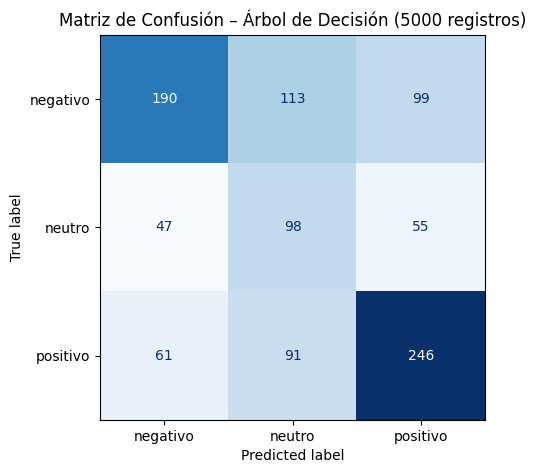

In [73]:
#Ejemplo de matriz con 5000 registros
visualizar_matriz_confusion(
    df_5000,
    model_5000,
    vectorizer_5000,
    "Matriz de Confusión – Árbol de Decisión (5000 registros)"
)

In [74]:
def visualizar_matriz_confusion(df, model, vectorizer, titulo):
    """
    Muestra la matriz de confusión del modelo entrenado
    """

    # 1️⃣ Variables
    X_texto = df["review_body_clean"]
    X_longitud = df[['lenght_review_body']]
    y = df["sentiment"]

    # 2️⃣ Train / Test
    X_text_train, X_text_test, X_len_train, X_len_test, y_train, y_test = train_test_split(
        X_texto,
        X_longitud,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # 3️⃣ Vectorizar texto
    X_test_vec = vectorizer.transform(X_text_test)

    # 4️⃣ Unir variables (texto vectorizado + longitud)
    X_test_final = hstack([X_test_vec, X_len_test])

    # 5️⃣ Predicción
    y_pred = model.predict(X_test_final)

    # 6️⃣ Matriz de confusión
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=model.classes_
    )

    # 7️⃣ Visualización
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=model.classes_
    )

    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(titulo)
    plt.show()

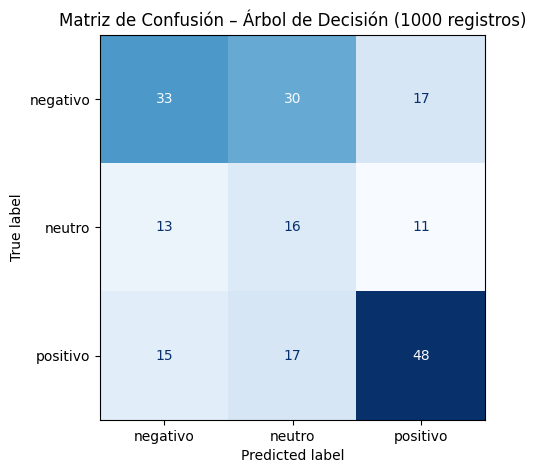

In [75]:
#Ejemplo de matriz con 1000 registros
visualizar_matriz_confusion(
    df_1000,
    model_1000,
    vectorizer_1000,
    "Matriz de Confusión – Árbol de Decisión (1000 registros)"
)

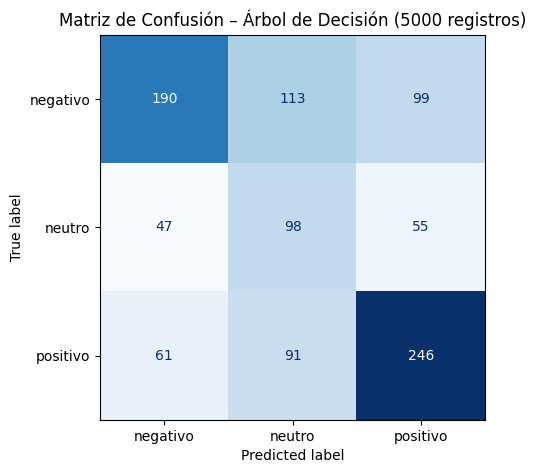

In [76]:
#Ejemplo de matriz con 5000 registros
visualizar_matriz_confusion(
    df_5000,
    model_5000,
    vectorizer_5000,
    "Matriz de Confusión – Árbol de Decisión (5000 registros)"
)

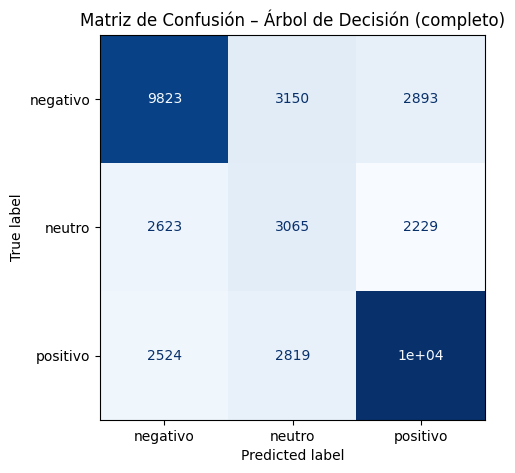

In [77]:
#Ejemplo de matriz con dataset completo
visualizar_matriz_confusion(
    df,
    model_completo,
    vectorizer_completo,
    "Matriz de Confusión – Árbol de Decisión (completo)"
)

**Accuracy (Precisión) adecuado o aceptable para este modelo Árbol de decisión**

🔹0.55 – 0.65 → aceptable

🔹0.65 – 0.70 → bueno

🔹> 0.70 → muy bueno pero bastante inusual para un árbol simple


En conclusión: El Árbol de Decisión está alrededor de **0.60–0.65**, está aceptable y estaría cumpliendo su rol como modelo comparativo respecto al de **Regresión Logística** y **Naive Bayes**.

**Muestra del porcentaje de datos utilizados para el entrenamiento**

| Dataset | Total | Entrenamiento (80%) | Prueba (20%) |
| ------- | ----- | ------------------- | ------------ |
| 500     | 500   | 400                 | 100          |
| 1000    | 1000  | 800                 | 200          |
| 5000    | 5000  | 4000                | 1000         |


**Comparación de resultados del entrenamiento con los distintos tamaños**

In [78]:
# El Árbol mejora con más datos, sin embargo es muy probable que siga siendo inferior al modelo de Regresión Logística aunque esto es esperable.
resultados = pd.DataFrame({
    'Dataset': ['500', '1000', '5000'],
    'Accuracy': [acc_500, acc_1000, acc_5000]
})

resultados

,Dataset,Accuracy
0,500,0.550
1,1000,0.485
2,5000,0.534


### **Función FINAL de predicción de sentimiento**

In [79]:
def predecir_sentimiento_arbol(texto, model, vectorizer, accuracy):
    # Validación de entrada
    if texto is None or texto.strip() == "":
        return "⚠️ Por favor escriba un comentario."

    if len(texto.strip()) < 3:
        return "⚠️ El comentario debe tener al menos 3 caracteres."

    # Vectorizar texto
    texto_vec = vectorizer.transform([texto])

    # Longitud del texto
    longitud = np.array([[len(texto)]])

    # Unir variables
    X_nuevo = hstack([texto_vec, longitud])

    # Predicción del sentimiento
    sentimiento = model.predict(X_nuevo)[0]

    return f"Sentimiento: {sentimiento} | Accuracy del modelo: {round(accuracy, 2)}"

**Ejemplo: Prueba 1**

In [80]:
# Para inicar la función predicir | predecir_sentimiento_Arbol, se abre parentesís y entre comillar "" se escribe el comentario, adicionalmente se ingresa el modelo de entrenamiento en este caso 5000.
predecir_sentimiento_arbol(
    "el producto fue lamentable realmente es terrible",
    model_5000,
    vectorizer_5000,
    acc_5000
)

'Sentimiento: positivo | Accuracy del modelo: 0.53'

**Ejemplo: Prueba 2**

In [81]:
predecir_sentimiento_arbol("Muy mal producto de lo peor que me pude comprar",
model_5000,vectorizer_5000,acc_5000
                           )

'Sentimiento: positivo | Accuracy del modelo: 0.53'

**Ejemplo: Prueba 3**

In [82]:
predecir_sentimiento_arbol(
    "quizas no era lo que esperaba sinceramente me encuentro decepcionado",
    model_5000,
    vectorizer_5000,
    acc_5000
)

'Sentimiento: negativo | Accuracy del modelo: 0.53'

**Ejemplo: Prueba 4**

In [83]:
predecir_sentimiento_arbol(
    "me encuentro triste y disconforme no esperaba un producto tan simple",
    model_5000,
    vectorizer_5000,
    acc_5000
)

'Sentimiento: negativo | Accuracy del modelo: 0.53'

### **Conclusiones después de las pruebas**




El **Árbol de Decisión** se basa en reglas discretas sobre palabras individuales y no captura bien el contexto semántico ni las negaciones complejas. Es decir que el Árbol de Decisión NO entiende el contexto del lenguaje. El **token “muy”** aparece muchas veces en comentarios positivos del dataset. Por lo anterior, **Muy** inmediatamente lo asocia con **sentimiento positivo.**

🔹No suma evidencias

🔹No pondera bien contradicciones

🔹No entiende negaciones largas

Finalmente, una sola palabra “fuerte” domina toda la decisión. Es por eso se utilizó la Regresión Logística como modelo principal.

### **Código para guardar el modelo en formato pkl**

In [84]:
# Se guarda el modelo entrenado con 5000 registros
import joblib

# Guardar modelo, vectorizador y accuracy
joblib.dump(model_5000, 'arbol_decision_model.pkl')
joblib.dump(vectorizer_5000, 'arbol_decision_vectorizer.pkl')
joblib.dump(acc_5000, 'arbol_decision_accuracy.pkl')

print("✅ Modelo guardado correctamente en archivos .pkl")

✅ Modelo guardado correctamente en archivos .pkl


### **Código para cargar el modelo para después**

In [85]:
import joblib

model = joblib.load('arbol_decision_model.pkl')
vectorizer = joblib.load('arbol_decision_vectorizer.pkl')
accuracy = joblib.load('arbol_decision_accuracy.pkl')

In [86]:
def evaluar_y_guardar_resultados(
    df,
    model,
    vectorizer,
    modelo_arboldedecision,
    dataset_amazon
):
    """
    Evalúa el modelo y guarda métricas y matriz de confusión en CSV
    """

    #  Variables a considerar
    X_texto = df["review_body_clean"]
    X_longitud = df[['lenght_review_body']]
    y = df["sentiment"]

    #  Train / Test
    X_text_train, X_text_test, X_len_train, X_len_test, y_train, y_test = train_test_split(
        X_texto,
        X_longitud,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    #  Vectorizar texto
    X_test_vec = vectorizer.transform(X_text_test)

    #  Unir variables (texto vectorizado + longitud)
    X_test_final = hstack([X_test_vec, X_len_test])

    #  Predicción
    y_pred = model.predict(X_test_final)

    #  Métricas importantes para realizar la comparación con otros modelos
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    # Guardar métricas
    df_metricas = pd.DataFrame([{
        "Modelo": modelo_arboldedecision,
        "Dataset": dataset_amazon,
        "Accuracy": round(accuracy, 4),
        "Precision_macro": round(precision, 4),
        "Recall_macro": round(recall, 4),
        "F1_macro": round(f1, 4)
    }])

    metricas_arbol = f"metricas_{modelo_arboldedecision}_{dataset_amazon}.csv"
    df_metricas.to_csv(metricas_arbol, index=False)

    # Gráfica de Matriz de confusión
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=model.classes_
    )

    df_cm = pd.DataFrame(
        cm,
        index=model.classes_,
        columns=model.classes_
    )

    nombre_cm = f"confusion_{modelo_arboldedecision}_{dataset_amazon}.csv"
    df_cm.to_csv(nombre_cm)

    print(f"✔️ Guardados: {metricas_arbol} y {nombre_cm}")